<a href="https://colab.research.google.com/github/arnoldorlandostory/Starbuck_MobileApp_CustomerSegmentation_ML/blob/main/Data_Starbucks_Market_Segmentation_MobileApp_Arnold_Orlando.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import sklearn.cluster as cluster
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**0. Data Definition**

|**Fitur**|**Penjelasan**|
|---|---|
|customer_id (obj)|Kode unik pengenal setiap pelanggan (mencakup transaksi berulang dari >15.000 profil unik)|
|order_id (obj)|ID unik untuk setiap transaksi (±100.000 data)|
|order_date (obj)|Tanggal transaksi (Januari 2024 – Desember 2025)|
|order_time (obj)|Waktu transaksi dalam sehari (mengikuti pola jam sibuk seperti pagi, makan siang, dan sore)|
|day_of_week (obj)|Hari saat transaksi dilakukan (untuk analisis weekday vs weekend)|
|order_channel (obj)|Metode pemesanan (Mobile App, Drive-Thru, In-Store Cashier, atau Kiosk)|
|store_id (obj)|ID unik untuk masing-masing lokasi toko (±500 toko)|
|store_location_type (obj)|Tipe lokasi toko (Urban, Suburban, atau Rural)|
|region (obj)|Wilayah geografis (Northeast, Southeast, Midwest, West, Southwest)|
|customer_age_group (obj)|Kelompok umur pelanggan (18–24, 25–34, 35–44, 45–54, 55+)|
|customer_gender (obj)|Jenis kelamin pelanggan|
|is_rewards_member (bool)|Status keanggotaan rewards (True = member, False = non-member)|
|cart_size (int)|Jumlah item dalam satu transaksi (1–10 item)|
|num_customizations (int)|Jumlah kustomisasi pesanan (misalnya extra shot, syrup, susu, dll)|
|total_spend (float)|Total biaya transaksi dalam USD|
|fulfillment_time_min (float)|Waktu pemenuhan pesanan (menit dari pemesanan hingga diterima)|
|drink_category (obj)|Kategori minuman utama (Espresso, Brewed Coffee, Frappuccino, dll)|
|has_food_item (bool)|Menunjukkan apakah pesanan termasuk makanan (True/False)|
|order_ahead (bool)|Menunjukkan apakah pesanan dilakukan sebelumnya (khusus Mobile App)|
|customer_satisfaction (int)|Skor kepuasan pelanggan (1–5 berdasarkan pengalaman layanan)|









**1. Load Data**

In [2]:
#Fungsi untuk memasukan data
def read_data(fname):
  """
  Membaca file csv dan mengubahnya dalam bentuk Pandas Dataframe

  Parameters:
  fname: nama file csv (str)

  Returns:
  df: Pandas Dataframe
  """
  #Memasukan file
  df = pd.read_csv(fname)
  #Melakukan pengecekan bentuk data
  print(f'Bentuk Data : {df.shape}')
  return df


In [3]:
#Memasukan data
data = read_data('starbucks_customer_ordering_patterns.csv')

Bentuk Data : (100000, 20)


In [4]:
#Cek data yang di masukan
data

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,25/03/2024,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,18/07/2025,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,15/01/2025,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,30/07/2024,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,18/06/2024,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST_09857,ORD_00099996,17/09/2025,17:08,Wed,Mobile App,STR_016,Suburban,Northeast,45-54,Non-binary,True,4,0,15.18,3.2,Frappuccino,False,True,4
99996,CUST_09970,ORD_00099997,03/08/2024,08:07,Sat,Drive-Thru,STR_409,Rural,Southwest,35-44,Prefer not to say,True,5,2,16.71,5.5,Espresso,False,False,3
99997,CUST_04417,ORD_00099998,11/01/2025,16:05,Sat,In-Store Cashier,STR_191,Suburban,Northeast,55+,Female,False,3,0,9.12,3.3,Espresso,False,False,1
99998,CUST_07997,ORD_00099999,23/10/2025,18:32,Thu,Mobile App,STR_210,Rural,Southeast,18-24,Female,True,5,1,18.02,1.9,Other,False,False,2


**2. Data Validation**

In [5]:
#Melakukan pengecekan terhadap duplikasi data
data.duplicated().sum()

np.int64(0)

In [6]:
#Melakukan pengecekan terhadap data yang hilang
data.isnull().sum()

,0
customer_id,0
order_id,0
order_date,0
order_time,0
day_of_week,0
order_channel,0
store_id,0
store_location_type,0
region,0
customer_age_group,0


In [7]:
#melakukan pengecekan terhadap tipe data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-nul

Berdasarkan tipe data diatas, terdapat beberapa fitur dengan tipe data yang salah antara lain order_date dan order_time. Kedua fitur ini perlu diubah sesuai dengan tipe data idealnya

In [8]:
#Mengubah fitur order_date menjadi datetime
data['order_date'] = pd.to_datetime(data['order_date'],format='%d/%m/%Y')
#Mengubah fiture order_time menjadi datetime
data['order_time'] = pd.to_datetime(data['order_time'], format='%H:%M')

**3. Explanatory Data Analysis**

In [9]:
#Mengelompokan data numerik diskrit dan kontinu
num_diskrit_cols=['cart_size','num_customizations','customer_satisfaction']
num_kontinu_cols=['total_spend','fulfillment_time_min']
#Menyatukan seluruh kolom numerik
num_cols = num_diskrit_cols + num_kontinu_cols
#Mengelompokan data kategorik
cat_cols=['order_channel','store_location_type','region','customer_age_group','customer_gender','is_rewards_member','drink_category','has_food_item','order_ahead']

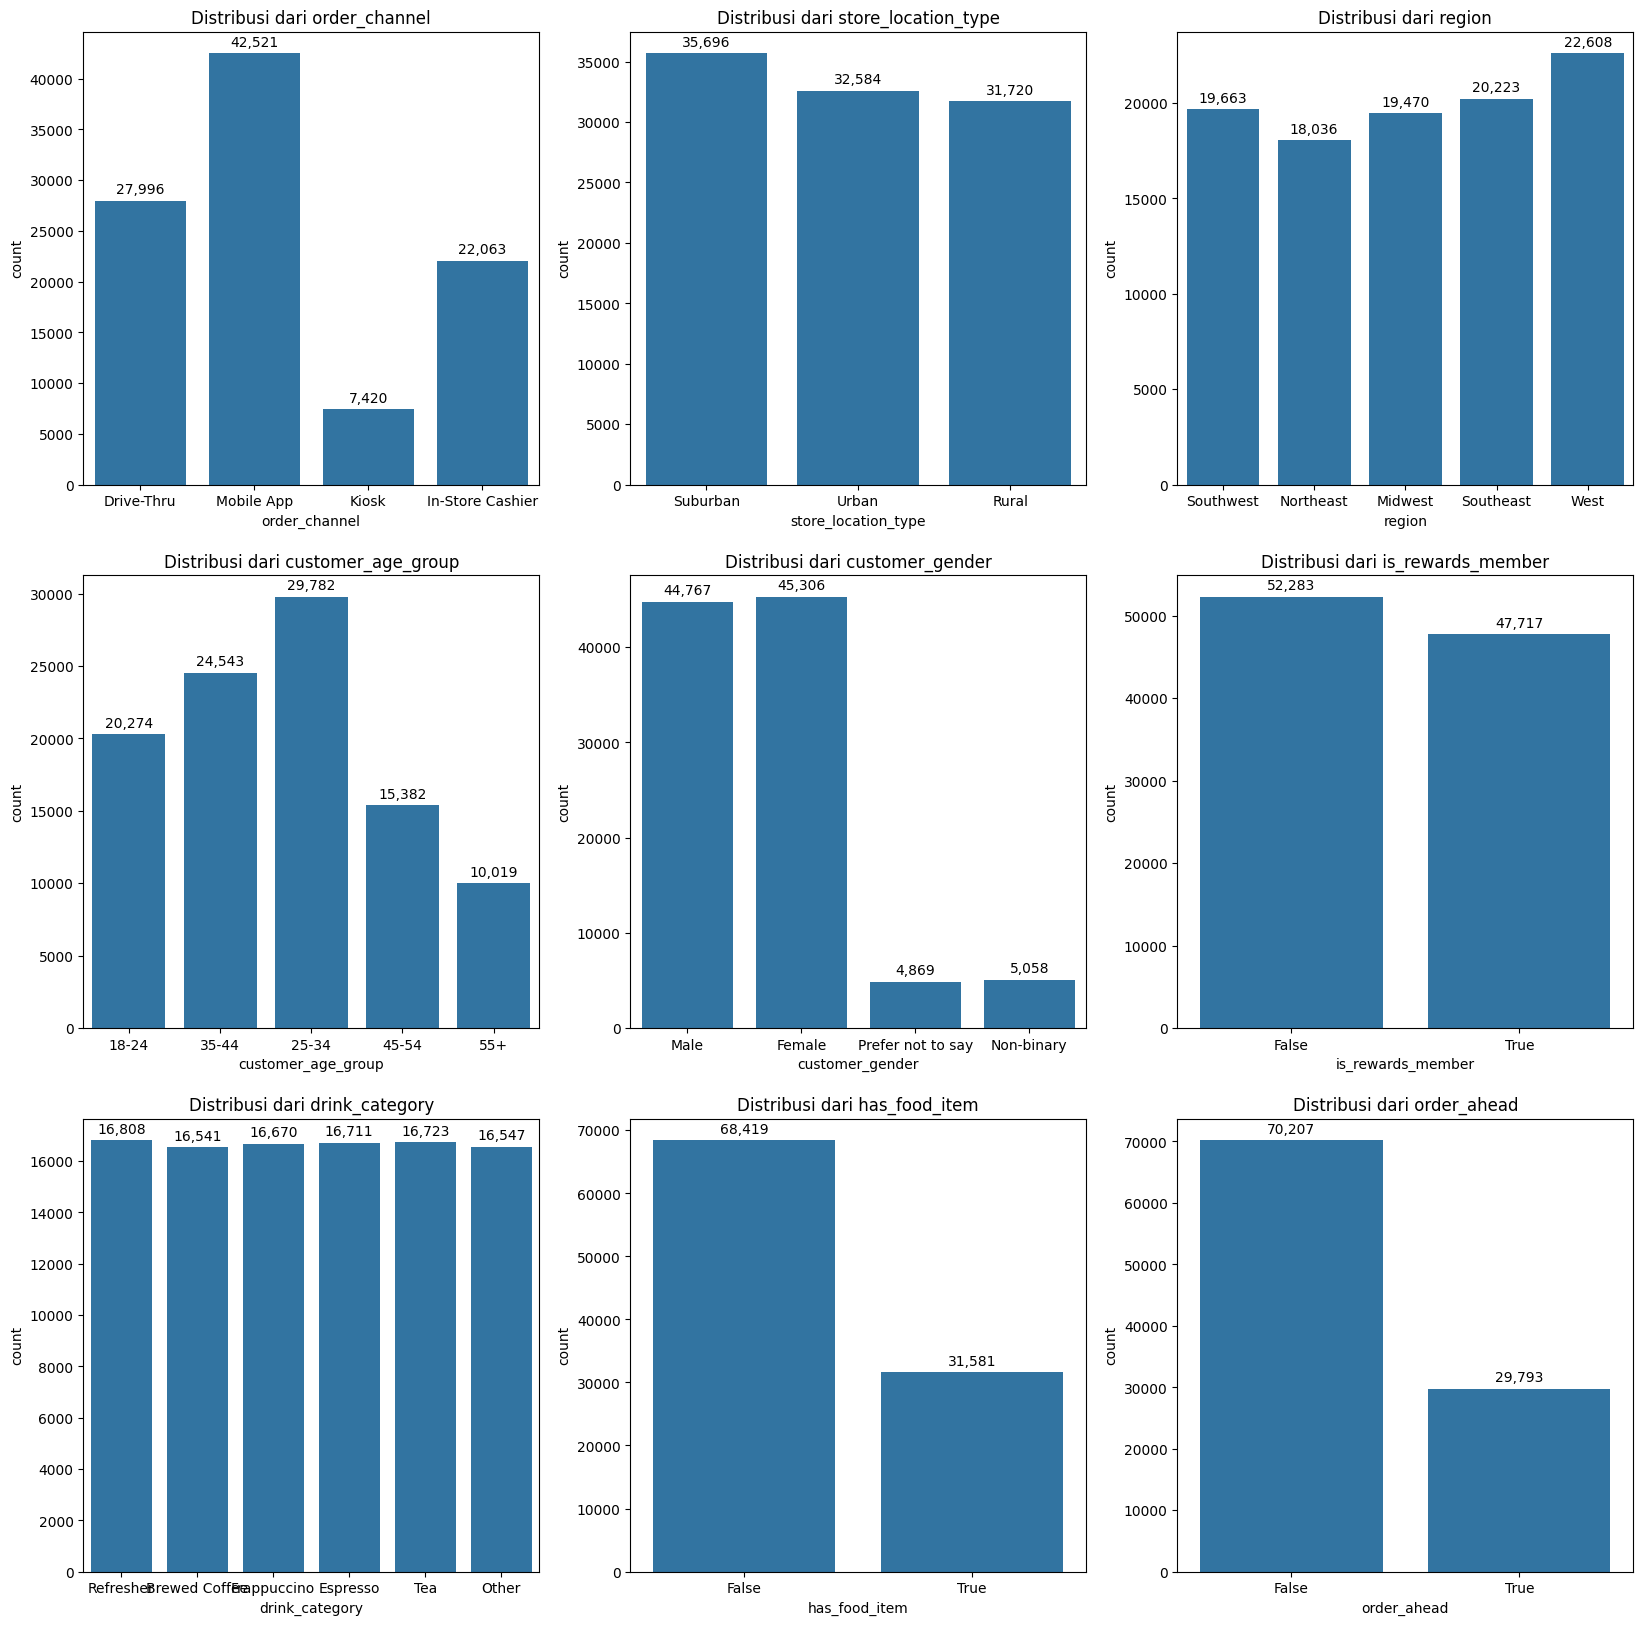

In [10]:
#Menampilkan pembagian dan distribusi data pada masing-masing fitur
#Pembagian data pada fitur kategorik
fig, ax =plt.subplots(nrows=3,ncols=3,figsize=(20,20))
axes = ax.flatten()

for i, col, in enumerate(cat_cols):
  sns.countplot(data=data,x=col,ax=axes[i])
  axes[i].set_title(f'Distribusi dari {col}')
  axes[i].bar_label(axes[i].containers[0], fmt='{:,.0f}', padding=3)

Berdasarkan hasil distribusi fitur kategorical diatas ditemukan bahwa:
1. Transaksi menggunakan Mobile App merupakan yang terbesar dibanding dengan chanel lain.
2. Pembelian kopi didominasi oleh pengguna dengan range umur 25-34 tahun
3. Mayoritas pembeli tidak tergabung dari rewards member
4. Mayoritas pembeli tidak membeli makanan dalam transaksinya
5. Mayoritas pembeli tidak memesan terlebih dahulu

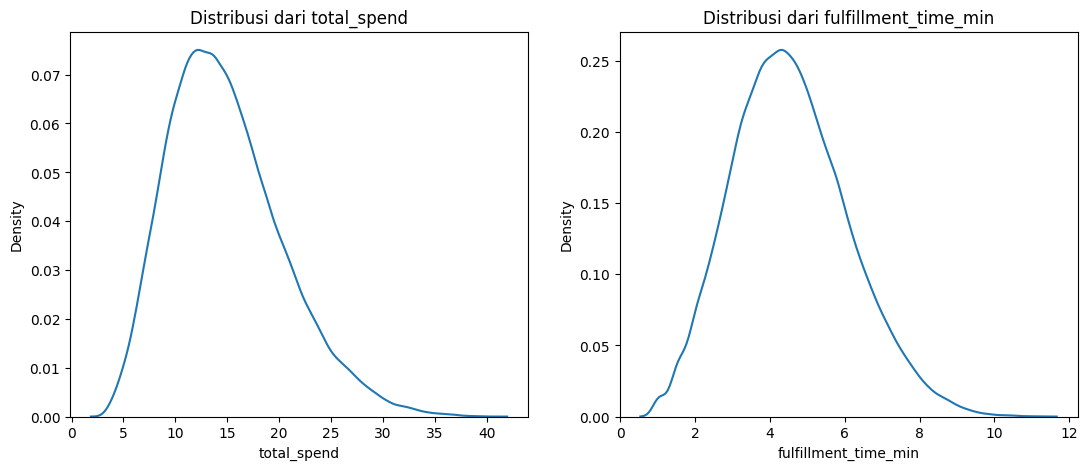

In [11]:
#Pembagian data pada fitur numerical kontinu
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(13,5))
axes = ax.flatten()

for i, col, in enumerate(num_kontinu_cols):
  sns.kdeplot(data[col],ax=axes[i])
  axes[i].set_title(f'Distribusi dari {col}')

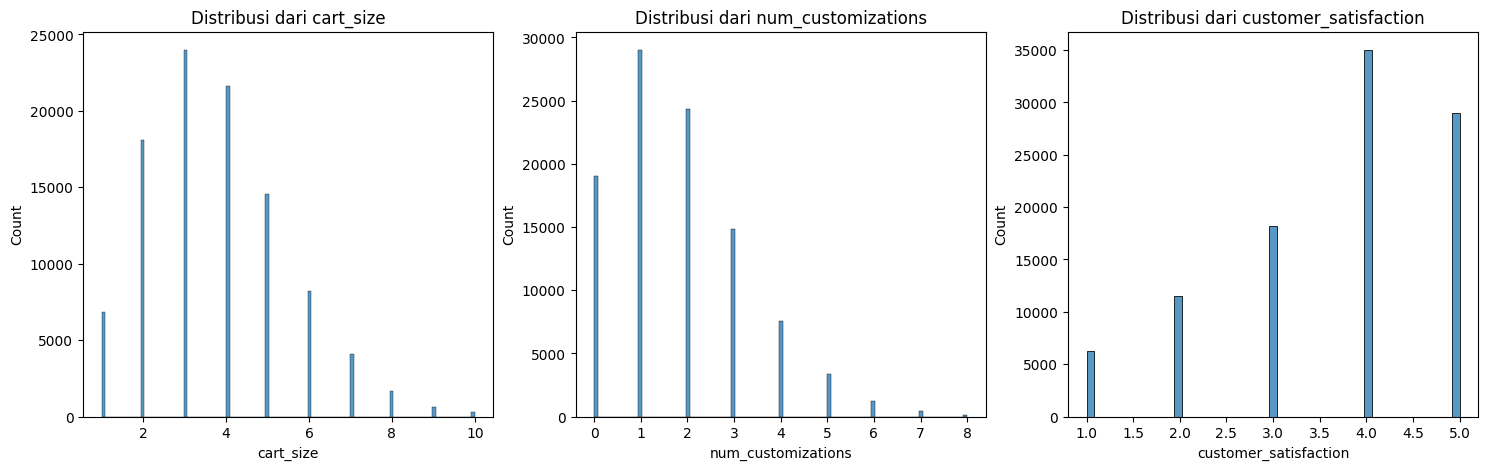

In [12]:
#Pembagian data pada fitur numerical diskrit
fig, ax =plt.subplots(nrows=1,ncols=3,figsize=(18,5))
axes = ax.flatten()

for i,col in enumerate(num_diskrit_cols):
  sns.histplot(data[col],ax=axes[i])
  axes[i].set_title(f'Distribusi dari {col}')

Berdasarkan hasil distribusi fitur numerical diatas ditemukan bahwa:
1. Mayoritas transaksi memiliki nominal $10
2. Sedangkan pemesanan dapat diselesaikan rata-rata dalam waktu 4 menit
3. Mayoritas pembeli memiliki 3 item dalam cart nya dengan jumlah kustomisasi 1 setiap transaksi
4. Mayoritas pembeli puas dengan pelayanan dari Starbucks

<Axes: >

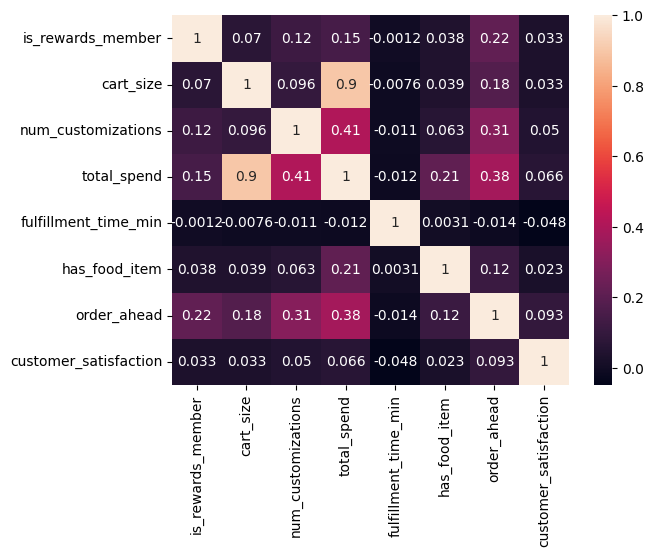

In [13]:
#Melakukan pengecekan terhadap korelasi antar fitur
co_mtx = data.corr(numeric_only=True)
sns.heatmap(co_mtx,annot=True)

Terdapat beberapa fitur yang memiliki korelasi satu dengan yang lain antara lain:
1. total_spend dengan cart_size dengan korelasi sebesar 0.91 mengindikasikan korelasi yang sangat kuat.
2. total_spend dengan num_customizations dengan korelasi sebesar 0.41 mengindikasikan korelasi yang sedang.
3. total_spend dengan order_ahead dengan korelasi sebesar 0.38 mengindikasikan korelasi yang rendah.
4. order_ahead dengan num customizations dengan korelasi sebesar 0.31 mengindikasikan korelasi yang rendah.

**4. Data Preprocessing**

In [14]:
#Mengambil fitur yang sesuai dengan tujuan penelitian
data_mobile = data[['customer_id','order_id','order_date','order_channel','is_rewards_member','total_spend','order_ahead']]
#Melakukan filter pada fitur order_channel untuk menampilkan data yang hanya Mobile App
data_mobile = data_mobile[data_mobile['order_channel']=='Mobile App']
data_mobile

,customer_id,order_id,order_date,order_channel,is_rewards_member,total_spend,order_ahead
1,CUST_08235,ORD_00000002,2025-07-18,Mobile App,True,9.52,True
5,CUST_04338,ORD_00000006,2025-08-30,Mobile App,True,21.13,False
6,CUST_11185,ORD_00000007,2025-10-05,Mobile App,True,12.95,True
7,CUST_00361,ORD_00000008,2025-12-17,Mobile App,True,26.33,False
8,CUST_13235,ORD_00000009,2024-02-03,Mobile App,True,12.17,True
...,...,...,...,...,...,...,...
99988,CUST_09209,ORD_00099989,2024-04-19,Mobile App,True,12.03,True
99989,CUST_09035,ORD_00099990,2025-03-30,Mobile App,True,18.27,False
99994,CUST_11970,ORD_00099995,2025-12-17,Mobile App,True,12.79,True
99995,CUST_09857,ORD_00099996,2025-09-17,Mobile App,True,15.18,True


In [15]:
#Membuat fungsi binary encoding
def ordinal_fit(data):
  ordinal=OrdinalEncoder(categories="auto")
  ordinal.fit(data)
  return ordinal

def transform_ord(data,ordinal):
  data_ordinal = ordinal.transform(data)
  return pd.DataFrame(data_ordinal,columns=data.columns,index=data.index)

In [16]:
#Melakukan binary encoding
ordinal = ordinal_fit(data_mobile[['is_rewards_member','order_ahead']])
data_mobile[['is_rewards_member','order_ahead']] = transform_ord(data_mobile[['is_rewards_member','order_ahead']],ordinal)
data_mobile

,customer_id,order_id,order_date,order_channel,is_rewards_member,total_spend,order_ahead
1,CUST_08235,ORD_00000002,2025-07-18,Mobile App,1.0,9.52,1.0
5,CUST_04338,ORD_00000006,2025-08-30,Mobile App,1.0,21.13,0.0
6,CUST_11185,ORD_00000007,2025-10-05,Mobile App,1.0,12.95,1.0
7,CUST_00361,ORD_00000008,2025-12-17,Mobile App,1.0,26.33,0.0
8,CUST_13235,ORD_00000009,2024-02-03,Mobile App,1.0,12.17,1.0
...,...,...,...,...,...,...,...
99988,CUST_09209,ORD_00099989,2024-04-19,Mobile App,1.0,12.03,1.0
99989,CUST_09035,ORD_00099990,2025-03-30,Mobile App,1.0,18.27,0.0
99994,CUST_11970,ORD_00099995,2025-12-17,Mobile App,1.0,12.79,1.0
99995,CUST_09857,ORD_00099996,2025-09-17,Mobile App,1.0,15.18,1.0


In [17]:
#Melakukan groupby setiap pembeli
data_groupby = data_mobile.groupby('customer_id').agg(
    #Data order
    order_id_cnt              = ('order_id',             'count'),
    order_date_max            = ('order_date',           'max'),
    total_spend           = ('total_spend',          'sum'),
    rewards_member     = ('is_rewards_member',    'mean'),
    order_ahead           = ('order_ahead',           'mean'),
).reset_index()
data_groupby.head()

,customer_id,order_id_cnt,order_date_max,total_spend,rewards_member,order_ahead
0,CUST_00001,3,2025-05-26,49.73,0.666667,1.000000
1,CUST_00002,7,2025-10-30,123.62,0.571429,0.714286
2,CUST_00003,3,2025-10-08,50.55,0.666667,0.666667
3,CUST_00004,2,2025-08-01,32.58,0.500000,0.500000
4,CUST_00007,3,2024-12-10,64.36,0.666667,0.666667


**4.1. Melakukan RFM Analysis**

In [18]:
#Menghitung Recency
#Mengambil tanggal maksimal pada dataset
max_date = data_groupby['order_date_max'].max()

#Menghitung jarak tanggal maksimal data dengan maksimal pengguna
data_groupby['recency'] = (max_date - data_groupby['order_date_max']).dt.days
data_groupby.head()

,customer_id,order_id_cnt,order_date_max,total_spend,rewards_member,order_ahead,recency
0,CUST_00001,3,2025-05-26,49.73,0.666667,1.000000,218
1,CUST_00002,7,2025-10-30,123.62,0.571429,0.714286,61
2,CUST_00003,3,2025-10-08,50.55,0.666667,0.666667,83
3,CUST_00004,2,2025-08-01,32.58,0.500000,0.500000,151
4,CUST_00007,3,2024-12-10,64.36,0.666667,0.666667,385


In [19]:
#Menghitung Frequency
#Frequency telah didapatkan dari hasil count order_id saat groupby
data_groupby.rename(columns={'order_id_cnt': 'frequency'}, inplace=True)
data_groupby.head()

,customer_id,frequency,order_date_max,total_spend,rewards_member,order_ahead,recency
0,CUST_00001,3,2025-05-26,49.73,0.666667,1.000000,218
1,CUST_00002,7,2025-10-30,123.62,0.571429,0.714286,61
2,CUST_00003,3,2025-10-08,50.55,0.666667,0.666667,83
3,CUST_00004,2,2025-08-01,32.58,0.500000,0.500000,151
4,CUST_00007,3,2024-12-10,64.36,0.666667,0.666667,385


In [39]:
#Menghitung Monetary
#Monetary telah didapatkan dari hasil penjumlahan total_spend saat groupby
data_groupby.rename(columns={'total_spend': 'monetary'}, inplace=True)
data_groupby.head()

,customer_id,frequency,order_date_max,monetary,rewards_member,order_ahead,recency
0,CUST_00001,3,2025-05-26,49.73,0.666667,1.000000,218
1,CUST_00002,7,2025-10-30,123.62,0.571429,0.714286,61
2,CUST_00003,3,2025-10-08,50.55,0.666667,0.666667,83
3,CUST_00004,2,2025-08-01,32.58,0.500000,0.500000,151
4,CUST_00007,3,2024-12-10,64.36,0.666667,0.666667,385


In [40]:
#Membuat tabel hasil rfm yang berisi fitur yang dibutuhkan untuk proses clustering
data_rfm = data_groupby[['recency','frequency','monetary','rewards_member','order_ahead']]
data_rfm.head()

,recency,frequency,monetary,rewards_member,order_ahead
0,218,3,49.73,0.666667,1.000000
1,61,7,123.62,0.571429,0.714286
2,83,3,50.55,0.666667,0.666667
3,151,2,32.58,0.500000,0.500000
4,385,3,64.36,0.666667,0.666667


**4.2. Scaling Data**

In [22]:
#Membuat fungsi penskalaan data
def scale_data(data):
  scaler = StandardScaler()
  scaler.fit(data)
  return scaler

def transform_scale(data,scale):
  data_scale = scaler.transform(data)
  return pd.DataFrame(data_scale,columns=data.columns,index=data.index)

In [23]:
#Melakukan penskalaan data
scaler = scale_data(data_rfm)
data_scaled = transform_scale(data_rfm,scaler)
data_scaled

,recency,frequency,monetary,rewards_member,order_ahead
0,0.055076,-0.082303,-0.213090,0.060435,0.969676
1,-0.836271,2.187418,1.998346,-0.234345,0.047450
2,-0.711369,-0.082303,-0.188549,0.060435,-0.106254
3,-0.325308,-0.649733,-0.726369,-0.455430,-0.644219
4,1.003196,-0.082303,0.224768,0.060435,-0.106254
...,...,...,...,...,...
13515,1.417644,-0.082303,0.198730,1.092164,-0.106254
13516,-1.182591,2.187418,1.739462,-0.234345,0.047450
13517,-0.257180,-1.217163,-1.270473,1.092164,0.969676
13518,-0.160664,0.485128,0.260981,1.092164,0.969676


**5. Modelling**

**5.1. PCA**

In [24]:
#Membuat fungsi PCA
def transform_pca(data):
  data_pca = PCA(svd_solver="auto",random_state=42)
  data_pca.fit(data_scaled)

  for i in range(1, len(data_pca.explained_variance_ratio_)+1):
    sum_of_variance = sum(data_pca.explained_variance_ratio_[:i]) *100
    print(f'komponen n = {i} memiliki variance sebesar {sum_of_variance}')

  print()
  n_comp = int(input('n_components : '))
  data_pca = PCA(n_components=n_comp,random_state=42)
  data_pca.fit(data_scaled)

  pca_components = data_pca.components_
  pca_components = pd.DataFrame(pca_components, columns=data_scaled.columns)
  return pca_components, data_pca

In [25]:
#Menentukan jumlah PC yang sesuai
pca_component, data_pca = transform_pca(data = data_scaled)

komponen n = 1 memiliki variance sebesar 45.281648771344415
komponen n = 2 memiliki variance sebesar 65.36050024796226
komponen n = 3 memiliki variance sebesar 85.3306528123386
komponen n = 4 memiliki variance sebesar 99.14959678341629
komponen n = 5 memiliki variance sebesar 99.99999999999999

n_components : 4


Penentuan 4 komponen dikarenakan 4 komponen mampu menjelaskan 99.1% varian data

In [26]:
#Menerapkan jumlah PC optimal
pca_final = data_pca.transform(data_scaled)
cols = [f'PC_{i+1}' for i in range(pca_final.shape[1])]
pca_final = pd.DataFrame(pca_final, columns=cols, index=data_scaled.index)
pca_final

,PC_1,PC_2,PC_3,PC_4
0,-0.196030,0.707777,0.671132,0.030634
1,3.028044,0.068955,-0.156535,0.563743
2,0.140392,-0.051929,-0.015388,-0.732897
3,-0.733472,-0.112314,-0.755697,-0.744717
4,-0.356318,-0.204752,-0.030971,0.932930
...,...,...,...,...
13515,-0.569229,-0.897616,0.755274,1.237336
13516,3.017532,0.107736,-0.152645,0.170322
13517,-1.461517,0.166411,1.470743,-0.983680
13518,0.546692,0.017618,1.458776,0.101808


**5.2 Elbow Method**

In [27]:
#Menghitung wss/inertia
wss =[]
nilai_k = np.arange(1,12)
for k in nilai_k:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(pca_final)
  wss.append(kmeans.inertia_)

In [28]:
#Menampilkan nilai wss
wss_tabel = pd.DataFrame({"Clusters":nilai_k,"Wss":wss})
wss_tabel

,Clusters,Wss
0,1,67025.127426
1,2,47211.861690
2,3,39597.434041
3,4,32974.848312
4,5,27783.907741
5,6,24987.673663
6,7,22860.379966
7,8,20639.173577
8,9,19312.361532
9,10,17925.611122


Text(0.5, 1.0, 'Elbow Method')

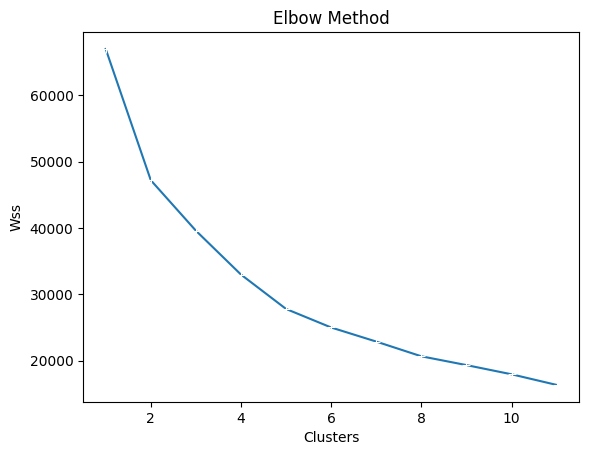

In [29]:
#Grafik hasil wss/inertia
fig, axes = plt.subplots()
sns.lineplot(x='Clusters',y='Wss',data=wss_tabel,marker="+")
axes.set_title(f'Elbow Method')

Berdasarkan grafik elbow method diatas belum dapat ditemukan jumlah klaster yang optimal maka dari itu dilakukan dengan silhouette score

**5.3. Silhouette Score**

In [30]:
#Menghitung Silhouette
sk_range = np.arange(2,11)
sil_score = []
for i in sk_range:
  labels=cluster.KMeans(n_clusters=i,init='k-means++',random_state=42).fit(pca_final).labels_
  score=metrics.silhouette_score(pca_final,labels,metric='euclidean',sample_size=1000,random_state=200)
  sil_score.append(score)
  print ("clusters "+str(i)+" = "
           +str(metrics.silhouette_score(pca_final,labels,metric="euclidean",sample_size=1000,random_state=200)))

clusters 2 = 0.24464797990259599
clusters 3 = 0.21974470259514872
clusters 4 = 0.23139990469551133
clusters 5 = 0.2518886967780045
clusters 6 = 0.240568370737699
clusters 7 = 0.2461359770728502
clusters 8 = 0.26601551054103834
clusters 9 = 0.2665900328945154
clusters 10 = 0.2555956521304493


In [31]:
#Menampilkan nilai silhouette
sil_tabel = pd.DataFrame({"Clusters":sk_range,"Silhouette":sil_score})
sil_tabel

,Clusters,Silhouette
0,2,0.244648
1,3,0.219745
2,4,0.231400
3,5,0.251889
4,6,0.240568
5,7,0.246136
6,8,0.266016
7,9,0.266590
8,10,0.255596


Text(0.5, 1.0, 'Silhouette Method')

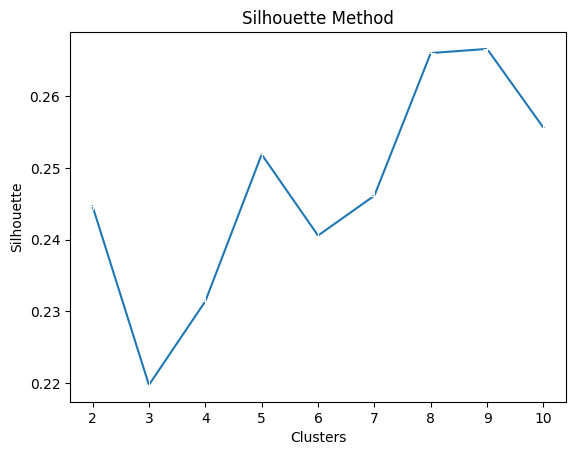

In [32]:
#Grafik hasil silhouette
fig, axes = plt.subplots()
sns.lineplot(x='Clusters',y='Silhouette',data=sil_tabel,marker="+")
axes.set_title(f'Silhouette Method')

Berdasarkan hasil silhouette ditemukan bahwa jumlah klaster yang optimal adalah 9 klaster

In [33]:
#Jumlah klaster optimal
n_clusters_best = sil_tabel["Silhouette"]
n_clusters_best = n_clusters_best.idxmax() + 2
n_clusters_best

9

In [34]:
#Menerapkan K-Means dengan jumlah klaster yang optimal
kmeans_pca_best = KMeans(n_clusters=n_clusters_best,init='k-means++',random_state=42)
kmeans_pca_best.fit(pca_final)

KMeans(n_clusters=9, random_state=42)

In [35]:
#Melihat nilai centroid untuk masing-masing klaster
centroid_pca_best = kmeans_pca_best.cluster_centers_
centroid_pca_best = pd.DataFrame(data = centroid_pca_best,
                                 columns = pca_final.columns)
centroid_pca_best

,PC_1,PC_2,PC_3,PC_4
0,2.387033,-0.047553,-0.006918,0.486387
1,0.397279,0.893487,-0.020677,-0.403512
2,-1.579944,2.045326,-0.921595,0.117889
3,-0.840434,-0.196424,-1.729377,-0.357047
4,-2.087466,-0.039622,1.405992,0.969245
5,-0.573632,0.322828,0.002164,0.914228
6,-1.554050,-1.995597,-0.349527,0.035711
7,0.524968,-0.621556,0.108936,-0.367507
8,-0.847064,0.112985,1.456143,-0.709818


In [36]:
#Melakukan inverse dari data PC menjadi fitur yang sebenarnya
centroid_pca_best_inv = data_pca.inverse_transform(centroid_pca_best.values)
centroid_pca_best_inv = pd.DataFrame(data = centroid_pca_best_inv, columns = data_scaled.columns)
centroid_pca_best_inv

,recency,frequency,monetary,rewards_member,order_ahead
0,-0.616880,1.664255,1.668532,-0.032516,0.038292
1,-0.605827,0.095952,0.079826,-0.571444,0.640504
2,0.651078,-1.054619,-1.048523,-2.003042,0.946107
3,0.081872,-0.626932,-0.630836,-1.166707,-1.305463
4,1.780327,-1.044510,-1.008626,1.074197,0.918446
5,1.044975,-0.109028,-0.080256,-0.248828,0.311247
6,0.877835,-0.892700,-0.878949,1.030216,-1.766217
7,-0.512590,0.251666,0.240011,0.495627,-0.423694
8,-0.280246,-0.757116,-0.776999,1.092141,0.951952


In [37]:
#Melakukan inverse dari data yang telah di scaling menjadi data yagn sebenarnya
centroid_best_inv = scaler.inverse_transform(centroid_pca_best_inv)
centroid_best_inv = pd.DataFrame(data=centroid_best_inv,columns=data_scaled.columns)
centroid_best_inv

,recency,frequency,monetary,rewards_member,order_ahead
0,99.643078,6.078012,112.600017,0.636636,0.711448
1,101.589985,3.314143,59.517113,0.462518,0.898019
2,322.978656,1.286456,21.815969,-0.000006,0.992698
3,222.719965,2.040183,35.771982,0.270199,0.295140
4,521.882213,1.304272,23.149027,0.994195,0.984129
5,392.358817,2.952901,54.168335,0.566749,0.796012
6,362.919132,1.571811,27.481876,0.979986,0.152394
7,118.012480,3.588564,64.869323,0.807269,0.568321
8,158.937071,1.810755,30.888284,0.999993,0.994509


**5.5. Hasil Clustering**

In [38]:
#Hasil Clustering
customer_cluster = centroid_best_inv
customer_cluster["cluster"] = [f"Cluster {i}" for i in range(1,len(customer_cluster) +1)]
cols = ["cluster"] +[c for c in customer_cluster.columns if c!='cluster']
customer_cluster = customer_cluster[cols]
customer_cluster

,cluster,recency,frequency,monetary,rewards_member,order_ahead
0,Cluster 1,99.643078,6.078012,112.600017,0.636636,0.711448
1,Cluster 2,101.589985,3.314143,59.517113,0.462518,0.898019
2,Cluster 3,322.978656,1.286456,21.815969,-0.000006,0.992698
3,Cluster 4,222.719965,2.040183,35.771982,0.270199,0.295140
4,Cluster 5,521.882213,1.304272,23.149027,0.994195,0.984129
5,Cluster 6,392.358817,2.952901,54.168335,0.566749,0.796012
6,Cluster 7,362.919132,1.571811,27.481876,0.979986,0.152394
7,Cluster 8,118.012480,3.588564,64.869323,0.807269,0.568321
8,Cluster 9,158.937071,1.810755,30.888284,0.999993,0.994509
